# K-nearest Neighbors (KNN)
K-nearest neighbors (KNN) is a simple, non-parametric, and lazy learning algorithm used for classification and regression tasks. It works by finding the K closest data points (neighbors) to a given input and making predictions based on the majority class (for classification) or the average value (for regression) of those neighbors.

In [67]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
# Example of KNN classifier on IRIS data
df = sns.load_dataset('iris')

In [69]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [71]:
# split the data into X and y
X = df.drop('species', axis=1)
y = df['species']

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Text(50.722222222222214, 0.5, 'True')

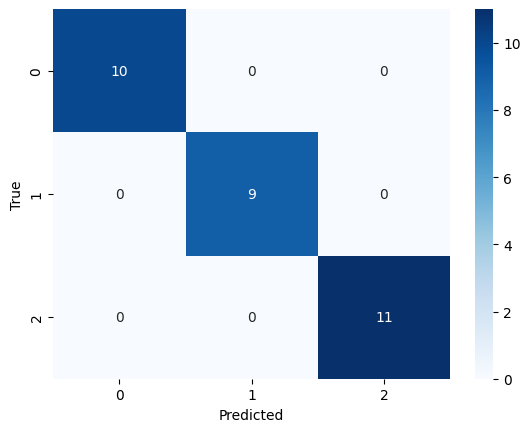

In [72]:
# train test split the data
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)
model = KNeighborsClassifier(n_neighbors=5)

# fit the model on training data
model.fit(X_train, y_train)

# predict the species for the test data
y_pred = model.predict(X_test)

# evaluate the model
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# plot the confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')

# Regression using KNN

In [73]:
# Regression problem on tips dataset
tips = sns.load_dataset('tips')
tips.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [74]:
# split the data into X and y
X = tips.drop('tip', axis=1)
y = tips['tip']

In [75]:
tips.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [76]:
# encode the categorical column using for loop and le(label encoder)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'category':
        X[col] = le.fit_transform(X[col])


In [77]:
# train test split the data and run the model
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)
model = KNeighborsRegressor(n_neighbors=5, metric='minkowski', p=2)

# fit the model on the training data
model = model.fit(X_train, y_train)

# predict the species for the test data
y_pred = model.predict(X_test)

# evaluate the model
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

print(f"Mean Squared Error:  {mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE : {root_mean_squared_error(y_test, y_pred)}")

Mean Squared Error:  0.8382265306122448
R2 Score: 0.3294034029001649
RMSE : 0.9155471209130881


In [78]:
X_test.head()

,total_bill,sex,smoker,day,time,size
24,19.82,1,0,1,0,2
6,8.77,1,0,2,0,2
153,24.55,1,0,2,0,4
211,25.89,1,1,1,0,4
198,13.00,0,1,3,1,2


In [79]:
# predict a specific value
model.predict([[45, 1, 0, 1, 1, 3]])

c:\Users\pc\.conda\envs\python_ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


array([4.946])

In [80]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score

# 1. Dataset load karna
df = sns.load_dataset('penguins')
df.head()




,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [ ]:
# Data Cleaning: Missing values ko khatam karna
df = df.dropna()

# Categorical data ko encode karna (Sex aur Island ko numbers mein badalna)
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['island'] = le.fit_transform(df['island'])

# Inputs (X) aur Target (y)
X_class = df.drop('species', axis=1)
y_class = df['species']

# Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# Scaling (KNN ke liye zaroori hai)
scaler = StandardScaler()
X_train_c = scaler.fit_transform(X_train_c)
X_test_c = scaler.transform(X_test_c)

# KNN Classifier model
knn_class = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn_class.fit(X_train_c, y_train_c)

# Predictions
y_pred_class = knn_class.predict(X_test_c)

print("--- KNN CLASSIFICATION REPORT (Species Prediction) ---")
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_class):.2f}")
print(classification_report(y_test_c, y_pred_class))j

--- KNN CLASSIFICATION REPORT (Species Prediction) ---
Accuracy: 0.99
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        31
   Chinstrap       0.93      1.00      0.96        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



In [82]:
# Hissa 2: KNN Regression (Body Mass predict karna)

# Ab hum 'species' ko bhi as a feature use karenge (pehle encode kar lete hain)
df['species_encoded'] = le.fit_transform(df['species'])

# Inputs (X) aur Target (y) - Hum 'body_mass_g' predict karenge
X_reg = df.drop(['body_mass_g', 'species'], axis=1)
y_reg = df['body_mass_g']

# Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Scaling
X_train_r = scaler.fit_transform(X_train_r)
X_test_r = scaler.transform(X_test_r)

# KNN Regressor model
knn_reg = KNeighborsRegressor(n_neighbors=5, metric='minkowski', p=2)
knn_reg.fit(X_train_r, y_train_r)

# Predictions
y_pred_reg = knn_reg.predict(X_test_r)

print("\n--- KNN REGRESSION METRICS (Body Mass Prediction) ---")
print(f"Mean Squared Error: {mean_squared_error(y_test_r, y_pred_reg):.2f}")
print(f"R2 Score: {r2_score(y_test_r, y_pred_reg):.2f}")

# Sample Results dekhna
comparison = pd.DataFrame({'Actual': y_test_r, 'Predicted': y_pred_reg})
print("\nSample Regression Results:")
print(comparison.head())


--- KNN REGRESSION METRICS (Body Mass Prediction) ---
Mean Squared Error: 81892.54
R2 Score: 0.87

Sample Regression Results:
     Actual  Predicted
30   3250.0     3315.0
317  4875.0     4980.0
79   4000.0     4145.0
201  3675.0     3495.0
63   4050.0     4065.0
